# 06 Improved Deep Learning Models

In this notebook, we improve the deep learning model for wearable stress detection.

The previous 1D CNN performed weaker than the classical machine learning model. Here, we improve the deep learning pipeline using a validation set, less aggressive downsampling, data augmentation, and a CNN-GRU architecture.

In [1]:
# Basic libraries for paths, arrays, tables, and plotting
from pathlib import Path
import copy
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn is used for subject-wise splitting and evaluation
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# PyTorch is used for deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
# Define main project folders
PROJECT_ROOT = Path("..")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

# Create output folders if they do not exist
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Check whether the required processed files exist
print("Processed data folder:", PROCESSED_DATA_DIR)
print("X_windows exists:", (PROCESSED_DATA_DIR / "X_windows.npy").exists())
print("y_windows exists:", (PROCESSED_DATA_DIR / "y_windows.npy").exists())
print("metadata exists:", (PROCESSED_DATA_DIR / "window_metadata.csv").exists())

Processed data folder: ..\data\processed
X_windows exists: True
y_windows exists: True
metadata exists: True


In [3]:
# Random seed helps make results more reproducible
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Set CUDA seed only if GPU is available
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

print("Random seed:", RANDOM_SEED)

Random seed: 42


In [4]:
# Use GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [5]:
# Load raw windowed data created in Notebook 02
X_windows = np.load(PROCESSED_DATA_DIR / "X_windows.npy")
y_windows = np.load(PROCESSED_DATA_DIR / "y_windows.npy")
metadata = pd.read_csv(PROCESSED_DATA_DIR / "window_metadata.csv")

# Show shapes to confirm correct loading
print("X_windows shape:", X_windows.shape)
print("y_windows shape:", y_windows.shape)
print("metadata shape:", metadata.shape)

X_windows shape: (2151, 21000, 4)
y_windows shape: (2151,)
metadata shape: (2151, 9)


In [6]:
# Signal order used in previous notebooks
SIGNAL_NAMES = ["ECG", "EDA", "Resp", "Temp"]

# Original WESAD labels used in our project
LABEL_NAMES = {
    1: "Neutral / Baseline",
    2: "Stress",
    3: "Amusement"
}

# Deep learning labels should start from 0
LABEL_TO_INDEX = {
    1: 0,
    2: 1,
    3: 2
}

INDEX_TO_LABEL = {
    0: "Neutral / Baseline",
    1: "Stress",
    2: "Amusement"
}

print("Signals:", SIGNAL_NAMES)
print("Label mapping:", LABEL_TO_INDEX)

Signals: ['ECG', 'EDA', 'Resp', 'Temp']
Label mapping: {1: 0, 2: 1, 3: 2}


In [7]:
# Downsampling reduces the time dimension and makes training faster
DOWNSAMPLE_FACTOR = 5

# Take every 5th sample from each window
X_downsampled = X_windows[:, ::DOWNSAMPLE_FACTOR, :]

# Convert to float32 because PyTorch works efficiently with float32
X_downsampled = X_downsampled.astype(np.float32)

print("Original X shape:", X_windows.shape)
print("Downsampled X shape:", X_downsampled.shape)

Original X shape: (2151, 21000, 4)
Downsampled X shape: (2151, 4200, 4)


In [8]:
# Convert labels from 1, 2, 3 into 0, 1, 2
y_indices = np.array([LABEL_TO_INDEX[label] for label in y_windows])

print("Original labels:", np.unique(y_windows))
print("Deep learning labels:", np.unique(y_indices))

for index, label_name in INDEX_TO_LABEL.items():
    print(index, "=", label_name)

Original labels: [1 2 3]
Deep learning labels: [0 1 2]
0 = Neutral / Baseline
1 = Stress
2 = Amusement


In [9]:
# Count all samples per class before splitting
overall_counts = np.bincount(y_indices, minlength=3)

print("Overall class distribution:")

for class_index, count in enumerate(overall_counts):
    print(INDEX_TO_LABEL[class_index], ":", count)

Overall class distribution:
Neutral / Baseline : 1154
Stress : 644
Amusement : 353


In [10]:
# Subject IDs are used for subject-independent splitting
groups = metadata["subject_id"]

# First split: separate final test subjects
test_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_SEED
)

train_val_index, test_index = next(
    test_splitter.split(X_downsampled, y_indices, groups=groups)
)

X_train_val = X_downsampled[train_val_index]
X_test_raw = X_downsampled[test_index]

y_train_val = y_indices[train_val_index]
y_test = y_indices[test_index]

groups_train_val = groups.iloc[train_val_index]
groups_test = groups.iloc[test_index]

# Second split: separate validation subjects from training subjects
val_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_SEED
)

train_index, val_index = next(
    val_splitter.split(X_train_val, y_train_val, groups=groups_train_val)
)

X_train_raw = X_train_val[train_index]
X_val_raw = X_train_val[val_index]

y_train = y_train_val[train_index]
y_val = y_train_val[val_index]

groups_train = groups_train_val.iloc[train_index]
groups_val = groups_train_val.iloc[val_index]

print("Train shape:", X_train_raw.shape)
print("Validation shape:", X_val_raw.shape)
print("Test shape:", X_test_raw.shape)

print("\nTrain subjects:", sorted(groups_train.unique()))
print("Validation subjects:", sorted(groups_val.unique()))
print("Test subjects:", sorted(groups_test.unique()))

Train shape: (1289, 4200, 4)
Validation shape: (429, 4200, 4)
Test shape: (433, 4200, 4)

Train subjects: ['S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S5', 'S9']
Validation subjects: ['S11', 'S7', 'S8']
Test subjects: ['S10', 'S4', 'S6']


In [11]:
# Check that subjects are fully separated
train_subjects = set(groups_train.unique())
val_subjects = set(groups_val.unique())
test_subjects = set(groups_test.unique())

train_val_overlap = train_subjects.intersection(val_subjects)
train_test_overlap = train_subjects.intersection(test_subjects)
val_test_overlap = val_subjects.intersection(test_subjects)

print("Train-validation overlap:", train_val_overlap)
print("Train-test overlap:", train_test_overlap)
print("Validation-test overlap:", val_test_overlap)

Train-validation overlap: set()
Train-test overlap: set()
Validation-test overlap: set()


In [12]:
# This helps us see whether one split is missing a class
train_counts = np.bincount(y_train, minlength=3)
val_counts = np.bincount(y_val, minlength=3)
test_counts = np.bincount(y_test, minlength=3)

distribution_df = pd.DataFrame({
    "class": [INDEX_TO_LABEL[i] for i in range(3)],
    "train_count": train_counts,
    "validation_count": val_counts,
    "test_count": test_counts
})

distribution_df

,class,train_count,validation_count,test_count
0,Neutral / Baseline,692,231,231
1,Stress,386,128,130
2,Amusement,211,70,72


In [13]:
# Calculate mean and std from training data only
train_mean = X_train_raw.mean(axis=(0, 1), keepdims=True)
train_std = X_train_raw.std(axis=(0, 1), keepdims=True)

# Avoid division by zero
train_std[train_std == 0] = 1.0

# Apply the same normalization to train, validation, and test data
X_train_norm = (X_train_raw - train_mean) / train_std
X_val_norm = (X_val_raw - train_mean) / train_std
X_test_norm = (X_test_raw - train_mean) / train_std

print("Train mean after normalization:", X_train_norm.mean(axis=(0, 1)))
print("Train std after normalization:", X_train_norm.std(axis=(0, 1)))

Train mean after normalization: [ 1.1591285e-05 -3.0173989e-02  3.4347745e-06  4.1615936e-01]
Train std after normalization: [0.9994281 1.004978  1.0000389 0.9100832]


In [14]:
# Convert from samples × time × channels to samples × channels × time
X_train_tensor = torch.tensor(X_train_norm).permute(0, 2, 1)
X_val_tensor = torch.tensor(X_val_norm).permute(0, 2, 1)
X_test_tensor = torch.tensor(X_test_norm).permute(0, 2, 1)

# Convert labels to PyTorch tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X_train_tensor:", X_train_tensor.shape)
print("X_val_tensor:", X_val_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)

print("y_train_tensor:", y_train_tensor.shape)
print("y_val_tensor:", y_val_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_train_tensor: torch.Size([1289, 4, 4200])
X_val_tensor: torch.Size([429, 4, 4200])
X_test_tensor: torch.Size([433, 4, 4200])
y_train_tensor: torch.Size([1289])
y_val_tensor: torch.Size([429])
y_test_tensor: torch.Size([433])


In [15]:
class AugmentedTimeSeriesDataset(Dataset):
    def __init__(self, X, y, augment=False):
        # Store signal windows and labels
        self.X = X
        self.y = y
        self.augment = augment
    
    def __len__(self):
        # Return number of samples
        return len(self.X)
    
    def __getitem__(self, index):
        # Get one sample and label
        x = self.X[index].clone()
        y = self.y[index]
        
        if self.augment:
            # Add small random noise
            noise = torch.randn_like(x) * 0.02
            x = x + noise
            
            # Randomly scale signal amplitude
            scale = 0.9 + torch.rand(1) * 0.2
            x = x * scale
            
            # Randomly shift signal slightly in time
            shift = torch.randint(-50, 51, (1,)).item()
            x = torch.roll(x, shifts=shift, dims=1)
        
        return x, y

In [16]:
# Batch size controls how many windows are processed together
BATCH_SIZE = 32

# Augmentation is used only for training data
train_dataset = AugmentedTimeSeriesDataset(
    X_train_tensor,
    y_train_tensor,
    augment=True
)

val_dataset = AugmentedTimeSeriesDataset(
    X_val_tensor,
    y_val_tensor,
    augment=False
)

test_dataset = AugmentedTimeSeriesDataset(
    X_test_tensor,
    y_test_tensor,
    augment=False
)

# DataLoaders create mini-batches for training and evaluation
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training batches: 41
Validation batches: 14
Testing batches: 14


In [17]:
# Count training samples in each class
train_class_counts = np.bincount(y_train, minlength=3)

# Calculate balanced class weights
num_classes = 3
total_train_samples = len(y_train)

class_weights = total_train_samples / (num_classes * train_class_counts)

# Convert weights to PyTorch tensor
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Training class counts:", train_class_counts)
print("Class weights:", class_weights)

Training class counts: [692 386 211]
Class weights: [0.62090559 1.11312608 2.03633491]


In [18]:
# Check one training batch to confirm shape is correct
batch_X, batch_y = next(iter(train_loader))

print("Batch X shape:", batch_X.shape)
print("Batch y shape:", batch_y.shape)
print("Batch labels:", batch_y[:10])

Batch X shape: torch.Size([32, 4, 4200])
Batch y shape: torch.Size([32])
Batch labels: tensor([0, 1, 1, 1, 0, 2, 0, 1, 1, 1])


In [19]:
class StressCNNGRU(nn.Module):
    def __init__(self, num_channels, num_classes):
        super().__init__()
        
        # CNN layers learn local patterns from physiological signals
        self.cnn = nn.Sequential(
            nn.Conv1d(num_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),
            
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),
            
            nn.Dropout(0.20)
        )
        
        # GRU learns temporal dependencies after CNN feature extraction
        self.gru = nn.GRU(
            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        # Final classifier predicts one of the three classes
        self.classifier = nn.Sequential(
            nn.Dropout(0.30),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        # Input shape: batch × channels × time
        x = self.cnn(x)
        
        # GRU expects batch × time × features
        x = x.permute(0, 2, 1)
        
        # GRU returns output for every time step
        output, hidden = self.gru(x)
        
        # Average all time steps into one feature vector
        x = output.mean(dim=1)
        
        # Predict class scores
        x = self.classifier(x)
        
        return x

In [20]:
# Number of input signal channels: ECG, EDA, Resp, Temp
num_channels = X_train_tensor.shape[1]

# Number of output classes: Neutral, Stress, Amusement
num_classes = 3

# Create model and move it to CPU or GPU
model = StressCNNGRU(
    num_channels=num_channels,
    num_classes=num_classes
).to(device)

# Weighted loss helps with class imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Adam optimizer updates model parameters
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# Scheduler reduces learning rate when validation F1 stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

print(model)

StressCNNGRU(
  (cnn): Sequential(
    (0): Conv1d(4, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (8): Dropout(p=0.2, inplace=False)
  )
  (gru): GRU(64, 64, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [21]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    # Put model into training mode
    model.train()
    
    total_loss = 0.0
    all_predictions = []
    all_targets = []
    
    for batch_X, batch_y in data_loader:
        # Move data to CPU or GPU
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Clear previous gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        loss.backward()
        
        # Update model weights
        optimizer.step()
        
        # Store loss and predictions
        total_loss += loss.item() * batch_X.size(0)
        predictions = torch.argmax(outputs, dim=1)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(batch_y.cpu().numpy())
    
    # Calculate average loss and metrics
    average_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(all_targets, all_predictions)
    macro_f1 = f1_score(all_targets, all_predictions, average="macro", zero_division=0)
    
    return average_loss, accuracy, macro_f1

In [22]:
def evaluate_model(model, data_loader, criterion, device):
    # Put model into evaluation mode
    model.eval()
    
    total_loss = 0.0
    all_predictions = []
    all_targets = []
    
    # No gradients are needed during evaluation
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            # Move data to CPU or GPU
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            # Forward pass only
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Store loss and predictions
            total_loss += loss.item() * batch_X.size(0)
            predictions = torch.argmax(outputs, dim=1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
    
    # Calculate evaluation metrics
    average_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(all_targets, all_predictions)
    macro_f1 = f1_score(all_targets, all_predictions, average="macro", zero_division=0)
    
    return average_loss, accuracy, macro_f1, np.array(all_targets), np.array(all_predictions)

In [23]:
# Maximum number of epochs
NUM_EPOCHS = 60

# Stop if validation F1 does not improve for this many epochs
PATIENCE = 10

# Store training history
history = []

best_val_f1 = 0.0
best_model_state = None
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    # Train model for one epoch
    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    # Evaluate model on validation set
    val_loss, val_acc, val_f1, _, _ = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )
    
    # Update learning rate based on validation F1
    scheduler.step(val_f1)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]["lr"]
    
    # Save epoch results
    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "train_macro_f1": train_f1,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "learning_rate": current_lr
    })
    
    # Save best model based on validation macro F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    
    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"LR: {current_lr:.6f}"
    )
    
    # Stop training if validation score does not improve
    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

print("Best validation macro F1:", best_val_f1)

Epoch 01/60 | Train Loss: 0.9373 | Train F1: 0.5038 | Val Loss: 2.1085 | Val F1: 0.1616 | LR: 0.001000
Epoch 02/60 | Train Loss: 0.7191 | Train F1: 0.6543 | Val Loss: 2.0222 | Val F1: 0.3958 | LR: 0.001000
Epoch 03/60 | Train Loss: 0.5663 | Train F1: 0.7193 | Val Loss: 2.7904 | Val F1: 0.2783 | LR: 0.001000
Epoch 04/60 | Train Loss: 0.5708 | Train F1: 0.7268 | Val Loss: 2.3183 | Val F1: 0.3723 | LR: 0.001000
Epoch 05/60 | Train Loss: 0.4494 | Train F1: 0.7923 | Val Loss: 2.7035 | Val F1: 0.4314 | LR: 0.001000
Epoch 06/60 | Train Loss: 0.3575 | Train F1: 0.8328 | Val Loss: 3.7674 | Val F1: 0.2760 | LR: 0.001000
Epoch 07/60 | Train Loss: 0.4006 | Train F1: 0.7993 | Val Loss: 3.2818 | Val F1: 0.2689 | LR: 0.001000
Epoch 08/60 | Train Loss: 0.3283 | Train F1: 0.8353 | Val Loss: 2.7896 | Val F1: 0.5248 | LR: 0.001000
Epoch 09/60 | Train Loss: 0.2645 | Train F1: 0.8784 | Val Loss: 4.1241 | Val F1: 0.2588 | LR: 0.001000
Epoch 10/60 | Train Loss: 0.3729 | Train F1: 0.8234 | Val Loss: 2.9118 | 

In [24]:
# Convert training history into a DataFrame
history_df = pd.DataFrame(history)

# Display the first few rows
history_df.head()

,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,learning_rate
0,1,0.937270,0.572537,0.503772,2.108499,0.298368,0.161616,0.001
1,2,0.719120,0.712956,0.654267,2.022160,0.424242,0.395780,0.001
2,3,0.566310,0.768037,0.719336,2.790396,0.349650,0.278330,0.001
3,4,0.570824,0.770365,0.726818,2.318251,0.414918,0.372261,0.001
4,5,0.449426,0.825446,0.792258,2.703462,0.470862,0.431448,0.001


In [25]:
# Save training history for later analysis and GitHub results
history_path = RESULTS_DIR / "improved_dl_training_history.csv"

history_df.to_csv(history_path, index=False)

print("Saved training history to:", history_path)

Saved training history to: ..\results\improved_dl_training_history.csv


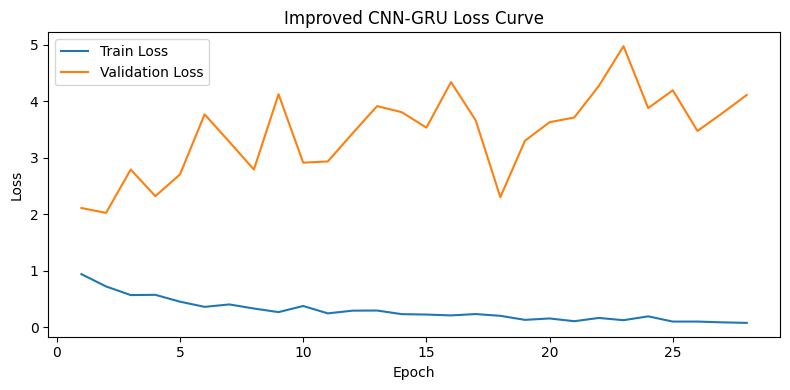

Saved figure to: ..\results\improved_dl_loss_curve.png


In [26]:
# Plot training and validation loss
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved CNN-GRU Loss Curve")
plt.legend()
plt.tight_layout()

output_path = RESULTS_DIR / "improved_dl_loss_curve.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

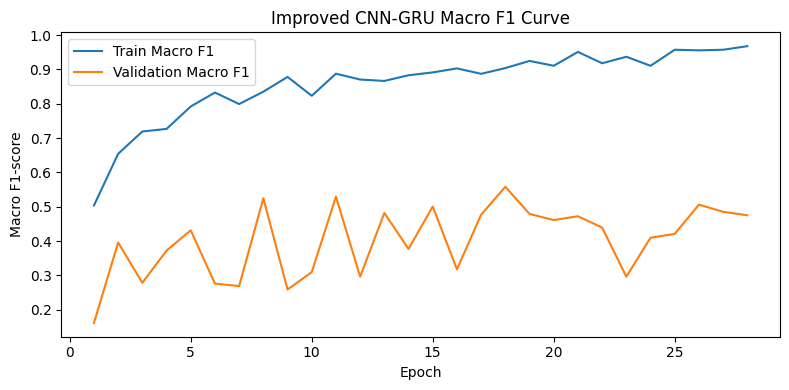

Saved figure to: ..\results\improved_dl_macro_f1_curve.png


In [27]:
# Plot training and validation macro F1-score
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="Train Macro F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("Improved CNN-GRU Macro F1 Curve")
plt.legend()
plt.tight_layout()

output_path = RESULTS_DIR / "improved_dl_macro_f1_curve.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

In [28]:
# Load the best model weights found during validation
model.load_state_dict(best_model_state)

print("Loaded best model with validation macro F1:", best_val_f1)

Loaded best model with validation macro F1: 0.5582580156162852


In [29]:
# Evaluate best model on final unseen test subjects
test_loss, test_acc, test_f1, y_true, y_pred = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

# Calculate extra metrics
test_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
test_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)

print("Final Test Loss:", round(test_loss, 4))
print("Final Test Accuracy:", round(test_acc, 4))
print("Final Test Macro Precision:", round(test_precision, 4))
print("Final Test Macro Recall:", round(test_recall, 4))
print("Final Test Macro F1:", round(test_f1, 4))

Final Test Loss: 3.0678
Final Test Accuracy: 0.4642
Final Test Macro Precision: 0.4543
Final Test Macro Recall: 0.3572
Final Test Macro F1: 0.3803


In [30]:
# Class names for readable report
class_names = [
    INDEX_TO_LABEL[0],
    INDEX_TO_LABEL[1],
    INDEX_TO_LABEL[2]
]

# Create detailed classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

                    precision    recall  f1-score   support

Neutral / Baseline       0.63      0.67      0.65       231
            Stress       0.68      0.31      0.42       130
         Amusement       0.05      0.10      0.07        72

          accuracy                           0.46       433
         macro avg       0.45      0.36      0.38       433
      weighted avg       0.55      0.46      0.48       433



In [31]:
# Save classification report as a text file
report_path = RESULTS_DIR / "improved_dl_classification_report.txt"

with open(report_path, "w") as file:
    file.write("Model: Improved CNN-GRU\n\n")
    file.write(report)

print("Saved classification report to:", report_path)

Saved classification report to: ..\results\improved_dl_classification_report.txt


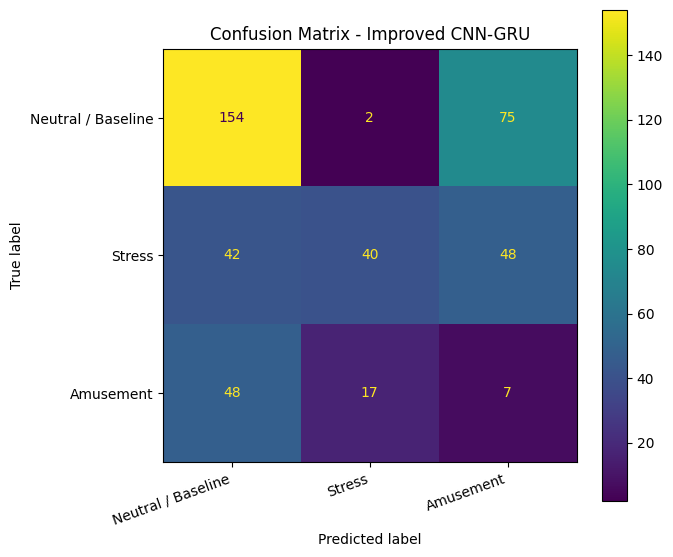

Saved confusion matrix to: ..\results\improved_dl_confusion_matrix.png


In [32]:
# Confusion matrix shows correct and incorrect predictions
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Improved CNN-GRU")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = RESULTS_DIR / "improved_dl_confusion_matrix.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved confusion matrix to:", output_path)

In [33]:
# Save final result summary
improved_dl_summary = pd.DataFrame([
    {
        "model": "CNN-GRU",
        "accuracy": test_acc,
        "macro_precision": test_precision,
        "macro_recall": test_recall,
        "macro_f1": test_f1,
        "best_validation_macro_f1": best_val_f1,
        "epochs_trained": len(history_df),
        "batch_size": BATCH_SIZE,
        "downsample_factor": DOWNSAMPLE_FACTOR,
        "input_channels": num_channels,
        "input_time_steps": X_train_tensor.shape[2],
        "training_samples": X_train_tensor.shape[0],
        "validation_samples": X_val_tensor.shape[0],
        "testing_samples": X_test_tensor.shape[0],
        "training_subjects": ", ".join(sorted(groups_train.unique())),
        "validation_subjects": ", ".join(sorted(groups_val.unique())),
        "testing_subjects": ", ".join(sorted(groups_test.unique()))
    }
])

summary_path = RESULTS_DIR / "improved_dl_summary.csv"

improved_dl_summary.to_csv(summary_path, index=False)

improved_dl_summary

,model,accuracy,macro_precision,macro_recall,macro_f1,best_validation_macro_f1,epochs_trained,batch_size,downsample_factor,input_channels,input_time_steps,training_samples,validation_samples,testing_samples,training_subjects,validation_subjects,testing_subjects
0,CNN-GRU,0.464203,0.45432,0.357194,0.380336,0.558258,28,32,5,4,4200,1289,429,433,"S13, S14, S15, S16, S17, S2, S3, S5, S9","S11, S7, S8","S10, S4, S6"


In [34]:
# Save model locally, not to GitHub
model_path = MODELS_DIR / "improved_cnn_gru_model.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "train_mean": train_mean,
    "train_std": train_std,
    "signal_names": SIGNAL_NAMES,
    "label_mapping": INDEX_TO_LABEL,
    "downsample_factor": DOWNSAMPLE_FACTOR,
    "model_name": "CNN-GRU"
}, model_path)

print("Saved improved model locally to:", model_path)

Saved improved model locally to: ..\models\improved_cnn_gru_model.pt


In [35]:
# Load previous results if available
ml_results_path = RESULTS_DIR / "ml_model_comparison.csv"
old_dl_summary_path = RESULTS_DIR / "dl_summary.csv"

comparison_rows = []

# Add best classical ML result
if ml_results_path.exists():
    ml_results = pd.read_csv(ml_results_path)
    best_ml_row = ml_results.sort_values(by="macro_f1", ascending=False).iloc[0]
    
    comparison_rows.append({
        "model": best_ml_row["model"],
        "type": "Classical ML",
        "accuracy": best_ml_row["accuracy"],
        "macro_f1": best_ml_row["macro_f1"]
    })

# Add previous 1D CNN result
if old_dl_summary_path.exists():
    old_dl_summary = pd.read_csv(old_dl_summary_path)
    old_dl_row = old_dl_summary.iloc[0]
    
    comparison_rows.append({
        "model": old_dl_row["model"],
        "type": "Deep Learning",
        "accuracy": old_dl_row["accuracy"],
        "macro_f1": old_dl_row["macro_f1"]
    })

# Add improved CNN-GRU result
comparison_rows.append({
    "model": "CNN-GRU",
    "type": "Improved Deep Learning",
    "accuracy": test_acc,
    "macro_f1": test_f1
})

comparison_df = pd.DataFrame(comparison_rows)

comparison_path = RESULTS_DIR / "improved_ml_vs_dl_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

comparison_df

,model,type,accuracy,macro_f1
0,Gradient Boosting,Classical ML,0.706697,0.577475
1,1D CNN,Deep Learning,0.378753,0.358429
2,CNN-GRU,Improved Deep Learning,0.464203,0.380336


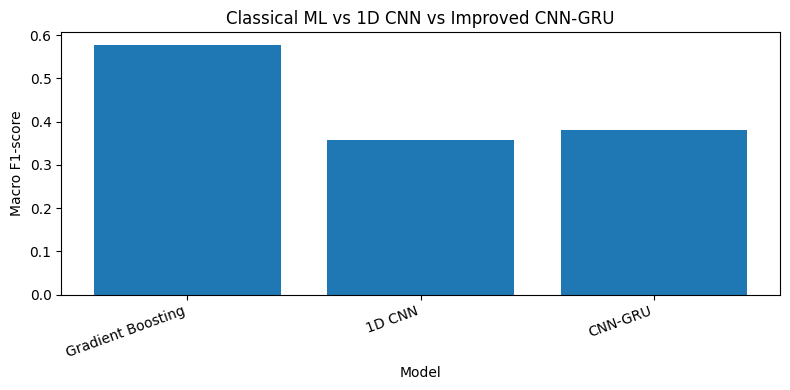

Saved figure to: ..\results\improved_ml_vs_dl_macro_f1.png


In [36]:
# Plot macro F1 comparison between models
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["model"], comparison_df["macro_f1"])
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.title("Classical ML vs 1D CNN vs Improved CNN-GRU")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = RESULTS_DIR / "improved_ml_vs_dl_macro_f1.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

In [37]:
# Select one test sample
sample_index = 0

sample_X = X_test_tensor[sample_index].unsqueeze(0).to(device)
sample_true_label = y_test_tensor[sample_index].item()

# Predict one sample
model.eval()

with torch.no_grad():
    output = model(sample_X)
    probabilities = torch.softmax(output, dim=1)
    predicted_label = torch.argmax(probabilities, dim=1).item()

print("True label:", INDEX_TO_LABEL[sample_true_label])
print("Predicted label:", INDEX_TO_LABEL[predicted_label])
print("Class probabilities:")

for class_index, probability in enumerate(probabilities.cpu().numpy()[0]):
    print(INDEX_TO_LABEL[class_index], ":", round(float(probability), 4))

True label: Neutral / Baseline
Predicted label: Neutral / Baseline
Class probabilities:
Neutral / Baseline : 0.9885
Stress : 0.0
Amusement : 0.0115
